In [5]:
"""
Creating Soccer Pizza Plots in Python

This notebook demonstrates how to create player "pizza plots" using Python
and synthetic football data.

Pizza plots are a popular way to visualise player performance across
multiple metrics using percentile rankings.

In this tutorial we will:

1. Create a synthetic dataset of male football players
2. Compute percentile rankings
3. Build pizza plots using mplsoccer
4. Compare players against:
    - all players
    - players in the same position
"""

'\nCreating Soccer Pizza Plots in Python\n\nThis notebook demonstrates how to create player "pizza plots" using Python\nand synthetic football data.\n\nPizza plots are a popular way to visualise player performance across\nmultiple metrics using percentile rankings.\n\nIn this tutorial we will:\n\n1. Create a synthetic dataset of male football players\n2. Compute percentile rankings\n3. Build pizza plots using mplsoccer\n4. Compare players against:\n    - all players\n    - players in the same position\n'

# Imports

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from matplotlib.patches import Patch
from mplsoccer import PyPizza
from scipy.stats import rankdata
import matplotlib.patheffects as patheffects

# Create Synthetic Dataset
#### This generates 50 players (10 per position).

In [38]:
import numpy as np
import pandas as pd

np.random.seed(14)

positions = [
    "Center Forward",
    "Wide Attacker",
    "Midfield",
    "Full Back",
    "Central Defender"
]

teams = ["United", "City", "Rovers", "Athletic", "Sporting"]

players = []
player_id = 1


def pos_dist(pos):

    if pos == "Center Forward":
        return {
            "shots_per90_total": np.random.normal(3.6, 0.8),
            "conversion_rate": np.random.normal(0.15, 0.03),
            "xG90": np.random.normal(0.48, 0.12),
            "NPxG90": np.random.normal(0.44, 0.10),
            "goals_per90": np.random.normal(0.42, 0.12),
            "shots_difficulty_index": np.random.normal(0.35, 0.07),

            "assists_per90": np.random.normal(0.12, 0.05),
            "xA90": np.random.normal(0.14, 0.05),
            "xGChain90": np.random.normal(0.70, 0.15),
            "xGBuildup90": np.random.normal(0.30, 0.10),
            "total_pass_value_per90": np.random.normal(0.55, 0.20),
            "possession_line_breaks_per90": np.random.normal(2.5, 0.8),

            "passes_attempted_per90": np.random.normal(35, 10),
            "avg_decision_quality": np.random.normal(0.60, 0.05),
            "completion_minus_xpass_per_pass": np.random.normal(-0.02, 0.02),
            "total_xthreat_available_per90": np.random.normal(0.6, 0.2),
            "offball_runs_total_per90": np.random.normal(36, 8),
            "possession_progression_total_per90": np.random.normal(5, 2),

            "obe_total_events_per90": np.random.normal(6, 2),
            "obe_possession_losses_forced_per90": np.random.normal(0.8, 0.3)
        }

    if pos == "Wide Attacker":
        return {
            "shots_per90_total": np.random.normal(2.9, 0.7),
            "conversion_rate": np.random.normal(0.13, 0.03),
            "xG90": np.random.normal(0.35, 0.10),
            "NPxG90": np.random.normal(0.32, 0.09),
            "goals_per90": np.random.normal(0.30, 0.10),
            "shots_difficulty_index": np.random.normal(0.42, 0.07),

            "assists_per90": np.random.normal(0.26, 0.08),
            "xA90": np.random.normal(0.29, 0.08),
            "xGChain90": np.random.normal(0.85, 0.20),
            "xGBuildup90": np.random.normal(0.42, 0.12),
            "total_pass_value_per90": np.random.normal(0.85, 0.25),
            "possession_line_breaks_per90": np.random.normal(3.2, 0.9),

            "passes_attempted_per90": np.random.normal(45, 12),
            "avg_decision_quality": np.random.normal(0.63, 0.05),
            "completion_minus_xpass_per_pass": np.random.normal(-0.01, 0.02),
            "total_xthreat_available_per90": np.random.normal(0.85, 0.2),
            "offball_runs_total_per90": np.random.normal(46, 10),
            "possession_progression_total_per90": np.random.normal(7, 2),

            "obe_total_events_per90": np.random.normal(7, 2),
            "obe_possession_losses_forced_per90": np.random.normal(1.0, 0.3)
        }

    if pos == "Midfield":
        return {
            "shots_per90_total": np.random.normal(1.6, 0.5),
            "conversion_rate": np.random.normal(0.10, 0.03),
            "xG90": np.random.normal(0.20, 0.06),
            "NPxG90": np.random.normal(0.18, 0.05),
            "goals_per90": np.random.normal(0.16, 0.05),
            "shots_difficulty_index": np.random.normal(0.52, 0.08),

            "assists_per90": np.random.normal(0.21, 0.07),
            "xA90": np.random.normal(0.23, 0.07),
            "xGChain90": np.random.normal(0.95, 0.25),
            "xGBuildup90": np.random.normal(0.55, 0.15),
            "total_pass_value_per90": np.random.normal(1.10, 0.30),
            "possession_line_breaks_per90": np.random.normal(4.0, 1.0),

            "passes_attempted_per90": np.random.normal(70, 15),
            "avg_decision_quality": np.random.normal(0.67, 0.04),
            "completion_minus_xpass_per_pass": np.random.normal(0.01, 0.02),
            "total_xthreat_available_per90": np.random.normal(0.9, 0.2),
            "offball_runs_total_per90": np.random.normal(30, 8),
            "possession_progression_total_per90": np.random.normal(9, 2),

            "obe_total_events_per90": np.random.normal(9, 3),
            "obe_possession_losses_forced_per90": np.random.normal(1.4, 0.4)
        }

    if pos == "Full Back":
        return {
            "shots_per90_total": np.random.normal(1.0, 0.4),
            "conversion_rate": np.random.normal(0.08, 0.03),
            "xG90": np.random.normal(0.12, 0.04),
            "NPxG90": np.random.normal(0.11, 0.04),
            "goals_per90": np.random.normal(0.08, 0.03),
            "shots_difficulty_index": np.random.normal(0.60, 0.08),

            "assists_per90": np.random.normal(0.19, 0.07),
            "xA90": np.random.normal(0.21, 0.07),
            "xGChain90": np.random.normal(0.88, 0.20),
            "xGBuildup90": np.random.normal(0.60, 0.15),
            "total_pass_value_per90": np.random.normal(0.92, 0.25),
            "possession_line_breaks_per90": np.random.normal(3.8, 0.9),

            "passes_attempted_per90": np.random.normal(60, 12),
            "avg_decision_quality": np.random.normal(0.64, 0.04),
            "completion_minus_xpass_per_pass": np.random.normal(0.00, 0.02),
            "total_xthreat_available_per90": np.random.normal(0.7, 0.2),
            "offball_runs_total_per90": np.random.normal(38, 9),
            "possession_progression_total_per90": np.random.normal(8, 2),

            "obe_total_events_per90": np.random.normal(11, 3),
            "obe_possession_losses_forced_per90": np.random.normal(1.8, 0.5)
        }

    if pos == "Central Defender":
        return {
            "shots_per90_total": np.random.normal(0.4, 0.2),
            "conversion_rate": np.random.normal(0.07, 0.03),
            "xG90": np.random.normal(0.06, 0.02),
            "NPxG90": np.random.normal(0.06, 0.02),
            "goals_per90": np.random.normal(0.05, 0.02),
            "shots_difficulty_index": np.random.normal(0.70, 0.08),

            "assists_per90": np.random.normal(0.05, 0.03),
            "xA90": np.random.normal(0.06, 0.03),
            "xGChain90": np.random.normal(0.55, 0.15),
            "xGBuildup90": np.random.normal(0.65, 0.15),
            "total_pass_value_per90": np.random.normal(0.65, 0.20),
            "possession_line_breaks_per90": np.random.normal(2.8, 0.8),

            "passes_attempted_per90": np.random.normal(75, 15),
            "avg_decision_quality": np.random.normal(0.66, 0.04),
            "completion_minus_xpass_per_pass": np.random.normal(0.02, 0.02),
            "total_xthreat_available_per90": np.random.normal(0.5, 0.15),
            "offball_runs_total_per90": np.random.normal(12, 4),
            "possession_progression_total_per90": np.random.normal(6, 2),

            "obe_total_events_per90": np.random.normal(15, 4),
            "obe_possession_losses_forced_per90": np.random.normal(2.4, 0.6)
        }


for pos in positions:
    for i in range(35):

        metrics = pos_dist(pos)

        player = {
            "player_id": player_id,
            "player_name": f"Player {player_id}",
            "position_group": pos,
            "team": np.random.choice(teams),
            "min": np.random.randint(700, 3000)
        }

        player.update(metrics)

        players.append(player)
        player_id += 1


df_fake = pd.DataFrame(players)

# Features, Synthetic Stats, and Helper Functions

In [39]:
FEATURE_GROUPS = {

    "Finishing": [
        "shots_per90_total",
        "shots_difficulty_index",
        "conversion_rate",
        "xG90",
        "NPxG90",
        "goals_per90"
    ],

    "Chance Generation": [
        "assists_per90",
        "xA90",
        "xGChain90",
        "xGBuildup90",
        "total_pass_value_per90",
        "possession_line_breaks_per90"
    ],

    "Involvement": [
        "passes_attempted_per90",
        "avg_decision_quality",
        "completion_minus_xpass_per_pass",
        "total_xthreat_available_per90",
        "offball_runs_total_per90",
        "possession_progression_total_per90"
    ],

    "Out of Possession": [
        "obe_total_events_per90",
        "obe_possession_losses_forced_per90"
    ]
}

GROUP_COLORS = {
    "Finishing": "#E63946",
    "Chance Generation": "#457B9D",
    "Involvement": "#2A9D8F",
    "Out of Possession": "#F4A261"
}

FEATURE_LABELS = {
    "conversion_rate": "Shot Conversion",
    "shots_per90_total": "Shots Volume",
    "xG90": "xG/90",
    "NPxG90": "NPxG/90",
    "goals_per90": "Goals/90",
    "shots_difficulty_index": "Shot Difficulty",
    "completion_minus_xpass_per_pass": "Pass Execution",
    "total_pass_value_per90": "Pass Value",
    "avg_decision_quality": "Pass Decision",
    "assists_per90": "Assists/90",
    "xA90": "xA/90",
    "xGChain90": "Possession xG",
    "xGBuildup90": "Build-up xG",
    "passes_attempted_per90": "Passing Volume",
    "possession_progression_total_per90": "Progression",
    "possession_line_breaks_per90": "Line Breaks",
    "offball_runs_total_per90": "Off-ball Runs",
    "total_xthreat_available_per90": "Receiving Threat",
    "obe_total_events_per90": "Defensive Actions",
    "obe_possession_losses_forced_per90": "Turnovers Forced"
}

ALL_FEATURES = sum(FEATURE_GROUPS.values(), [])

POSITION_FEATURES = {pos: ALL_FEATURES for pos in positions}

for feature in ALL_FEATURES:

    if "shots" in feature or "goals" in feature or "xG" in feature:
        df_fake[feature] = np.random.gamma(2, 0.4, len(df_fake))

    elif "passes" in feature:
        df_fake[feature] = np.random.normal(40, 10, len(df_fake))

    elif "conversion" in feature:
        df_fake[feature] = np.random.uniform(0.05, 0.25, len(df_fake))

    else:
        df_fake[feature] = np.random.normal(5, 2, len(df_fake))


def compute_percentiles(df, features, position=None):

    df_pct = df.copy()

    if position:
        df_pct = df_pct[df_pct["position_group"] == position].copy()

    for col in features:
        df_pct[col] = rankdata(df_pct[col]) / len(df_pct) * 100

    return df_pct


def get_feature_colors(features):

    colors = []

    for f in features:
        for group, group_features in FEATURE_GROUPS.items():
            if f in group_features:
                colors.append(GROUP_COLORS[group])
                break

    return colors


def lighten_color(color, amount=0.6):

    import matplotlib.colors as mc
    import colorsys

    c = colorsys.rgb_to_hls(*mc.to_rgb(color))

    return colorsys.hls_to_rgb(
        c[0],
        1 - amount * (1 - c[1]),
        c[2]
    )

# Pizza Plot Function and Examples

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mplsoccer import PyPizza
from scipy.stats import rankdata

from matplotlib.font_manager import FontProperties
from matplotlib.patches import Patch
import matplotlib.patheffects as patheffects
import matplotlib.colors as mc
import colorsys


# =================
# GLOBAL FONT SIZE
# =================
plt.rcParams["font.size"] = 11


# ========
# CONFIG
# ========
font_normal = FontProperties(family="DejaVu Sans", size=11)
font_bold = FontProperties(family="DejaVu Sans", weight="bold", size=14)


# ========
# FEATURE GROUPS
# ========
FEATURE_GROUPS = {

    "Finishing": [
        "shots_per90_total",
        "shots_difficulty_index",
        "conversion_rate",
        "xG90",
        "NPxG90",
        "goals_per90",
    ],

    "Chance Generation": [
        "assists_per90",
        "xA90",
        "xGChain90",
        "xGBuildup90",
        "total_pass_value_per90",
        "possession_line_breaks_per90",
    ],

    "Involvement": [
        "passes_attempted_per90",
        "avg_decision_quality",
        "completion_minus_xpass_per_pass",
        "total_xthreat_available_per90",
        "offball_runs_total_per90",
        "possession_progression_total_per90",
    ],

    "Out of Possession": [
        "obe_total_events_per90",
        "obe_possession_losses_forced_per90",
    ]
}


GROUP_COLORS = {
    "Finishing": "#E63946",
    "Chance Generation": "#457B9D",
    "Involvement": "#2A9D8F",
    "Out of Possession": "#F4A261"
}


# ========
# CUSTOM LABELS
# ========
FEATURE_LABELS = {

    "conversion_rate": "Shot Conversion",
    "shots_per90_total": "Shots Volume",
    "xG90": "xG/90",
    "NPxG90": "NPxG/90",
    "goals_per90": "Goals/90",
    "shots_difficulty_index": "Shot Difficulty",

    "completion_minus_xpass_per_pass": "Pass Execution",
    "total_pass_value_per90": "Pass Value",
    "avg_decision_quality": "Pass Decision Making",
    "assists_per90": "Assists/90",
    "xA90": "xA/90",
    "xGChain90": "Possession xG",
    "xGBuildup90": "Build-up Possession xG",

    "passes_attempted_per90": "Passing Volume",
    "possession_progression_total_per90": "Progression",
    "possession_line_breaks_per90": "Line Breaks",
    "offball_runs_total_per90": "Off-ball Runs",
    "total_xthreat_available_per90": "Receiving Threat",

    "obe_total_events_per90": "Defensive Actions",
    "obe_possession_losses_forced_per90": "Turnovers Forced",
}


# ========
# FEATURES
# ========
ALL_FEATURES = sum(FEATURE_GROUPS.values(), [])

POSITION_FEATURES = {
    "Center Forward": ALL_FEATURES,
    "Wide Attacker": ALL_FEATURES,
    "Midfield": ALL_FEATURES,
    "Full Back": ALL_FEATURES,
    "Central Defender": ALL_FEATURES
}


# ========
# HELPERS
# ========
def compute_percentiles(df, features, position=None):

    df_pct = df.copy()

    if position:
        df_pct = df_pct[df_pct["position_group"] == position].copy()

    for col in features:

        df_pct[col] = pd.to_numeric(df_pct[col], errors="coerce")
        df_pct[col] = df_pct[col].fillna(df_pct[col].median())

        df_pct[col] = rankdata(df_pct[col]) / len(df_pct) * 100

    return df_pct


def get_feature_colors(features):

    colors = []

    for f in features:

        for group, group_features in FEATURE_GROUPS.items():

            if f in group_features:
                colors.append(GROUP_COLORS[group])
                break

        else:
            colors.append("#999999")

    return colors


def lighten_color(color, amount=0.5):

    try:
        c = mc.cnames[color]
    except:
        c = color

    c = colorsys.rgb_to_hls(*mc.to_rgb(c))

    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])


# ========
# PIZZA PLOT
# ========
def plot_player_profile(df, player_names, mode="position"):

    df = df[df["min"] >= 500].copy()

    if isinstance(player_names, str):
        player_names = [player_names]

    n_players = len(player_names)

    width_per_plot = 5.8
    fig_width = max(6, width_per_plot * n_players)
    fig_height = 6.5

    fig, axes = plt.subplots(
        1,
        n_players,
        figsize=(fig_width, fig_height),
        subplot_kw=dict(polar=True),
        dpi=150
    )

    if n_players == 1:
        axes = [axes]

    plt.subplots_adjust(
        left=0.05,
        right=0.95,
        top=0.82,
        bottom=0.22,
        wspace=0.15
    )

    for ax, player_name in zip(axes, player_names):

        player_row = df[df["player_name"] == player_name]

        if player_row.empty:
            print(f"{player_name} not found")
            continue

        pos = player_row["position_group"].values[0]
        team = player_row["team"].values[0]

        features = POSITION_FEATURES[pos]

        if mode == "position":
            df_pct = compute_percentiles(df, features, position=pos)
        else:
            df_pct = compute_percentiles(df, features)

        values = df_pct.loc[
            df_pct["player_name"] == player_name,
            features
        ].values.flatten()

        values = np.nan_to_num(values, nan=0).round(1)

        features_wrapped = [
            FEATURE_LABELS.get(f, f).replace(" ", "\n")
            for f in features
        ]

        slice_colors = get_feature_colors(features)

        baker = PyPizza(
            params=features_wrapped,
            background_color="#FAFAFA",
            straight_line_color="#DDDDDD",
            straight_line_lw=1,
            last_circle_lw=1,
            last_circle_color="#DDDDDD",
            other_circle_lw=0,
            inner_circle_size=20
        )

        N = len(features)

        baker.make_pizza(
            [100]*N,
            ax=ax,
            slice_colors=[lighten_color(c,0.7) for c in slice_colors],
            kwargs_slices=dict(edgecolor="white", linewidth=1),
            kwargs_values=dict(alpha=0),
            kwargs_params=dict(
                fontsize=9,
                color="#222222",
                weight="bold",
                va="center",
                path_effects=[patheffects.withStroke(linewidth=2, foreground="white")]
            ),
            param_location=125
        )

        baker.make_pizza(
            values,
            ax=ax,
            slice_colors=slice_colors,
            kwargs_slices=dict(edgecolor="white", linewidth=1),
            kwargs_values=dict(
                fontsize=12,
                color="#222222",
                alpha=0.9,
                weight="bold",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1)
            ),
            kwargs_params=dict(
                fontsize=9,
                color="#222222",
                weight="bold",
                va="center",
                path_effects=[patheffects.withStroke(linewidth=2, foreground="white")]
            ),
            param_location=125
        )

        ax.set_title(
            f"{player_name} | {team}\n{pos}",
            fontproperties=font_bold,
            y=1.14
        )

    legend_elements = [
        Patch(facecolor=color, label=group)
        for group, color in GROUP_COLORS.items()
    ]

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=len(GROUP_COLORS),
        frameon=False,
        fontsize=13
    )

    footer_mode = "vs Position" if mode == "position" else "vs All Players"

    fig.text(
        0.5,
        0.0,
        f"Percentile Rank ({footer_mode}) | Illustrative example using synthetic player data",
        ha="center",
        fontsize=13,
        color="#555555"
    )

    plt.show()

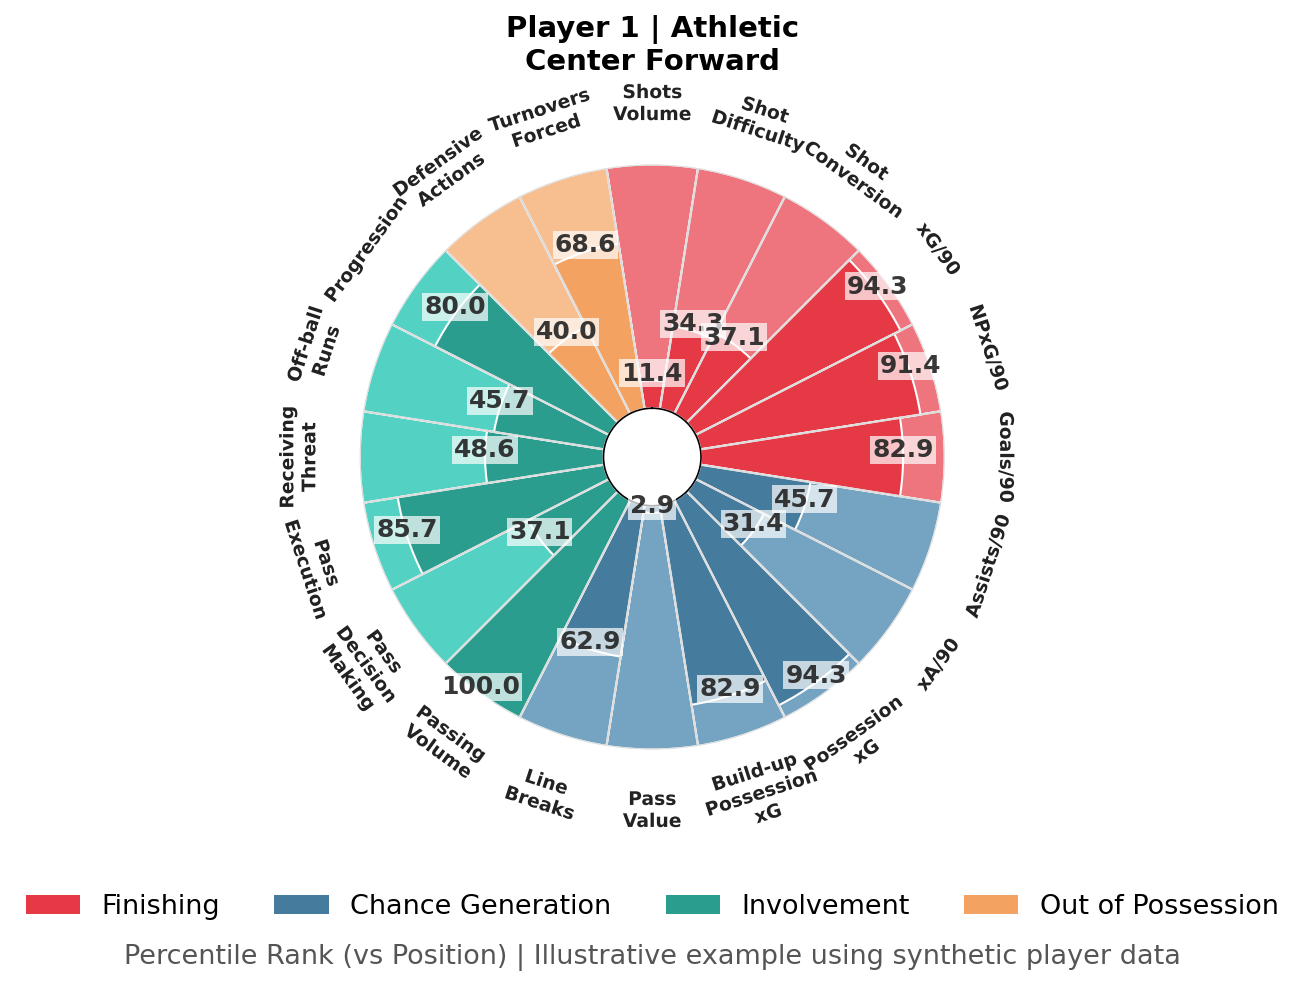

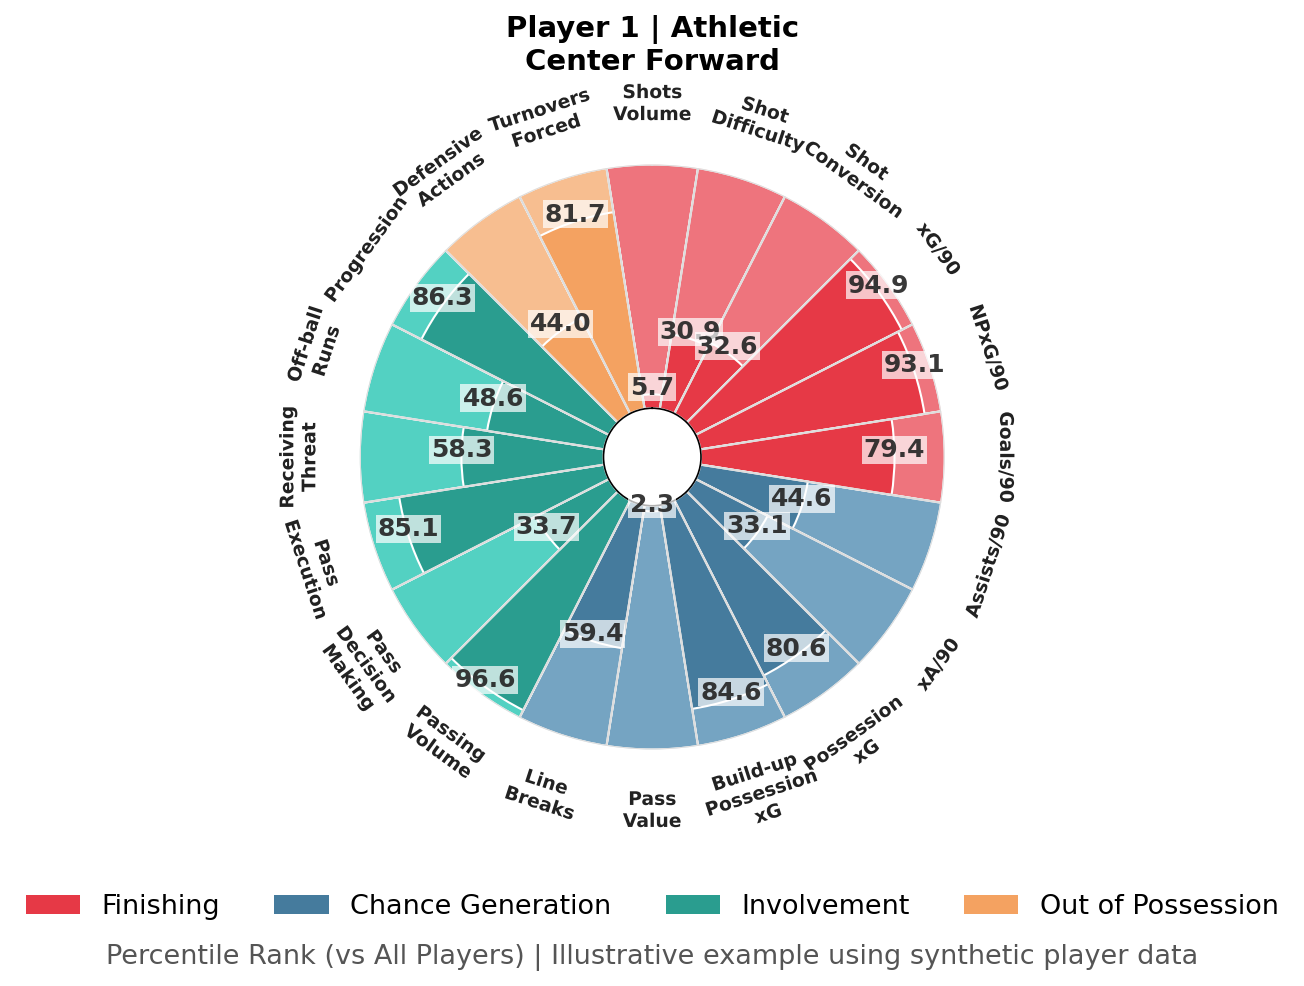

In [46]:
plot_player_profile(df_fake, "Player 1", mode="position")

plot_player_profile(df_fake, "Player 1", mode="global")

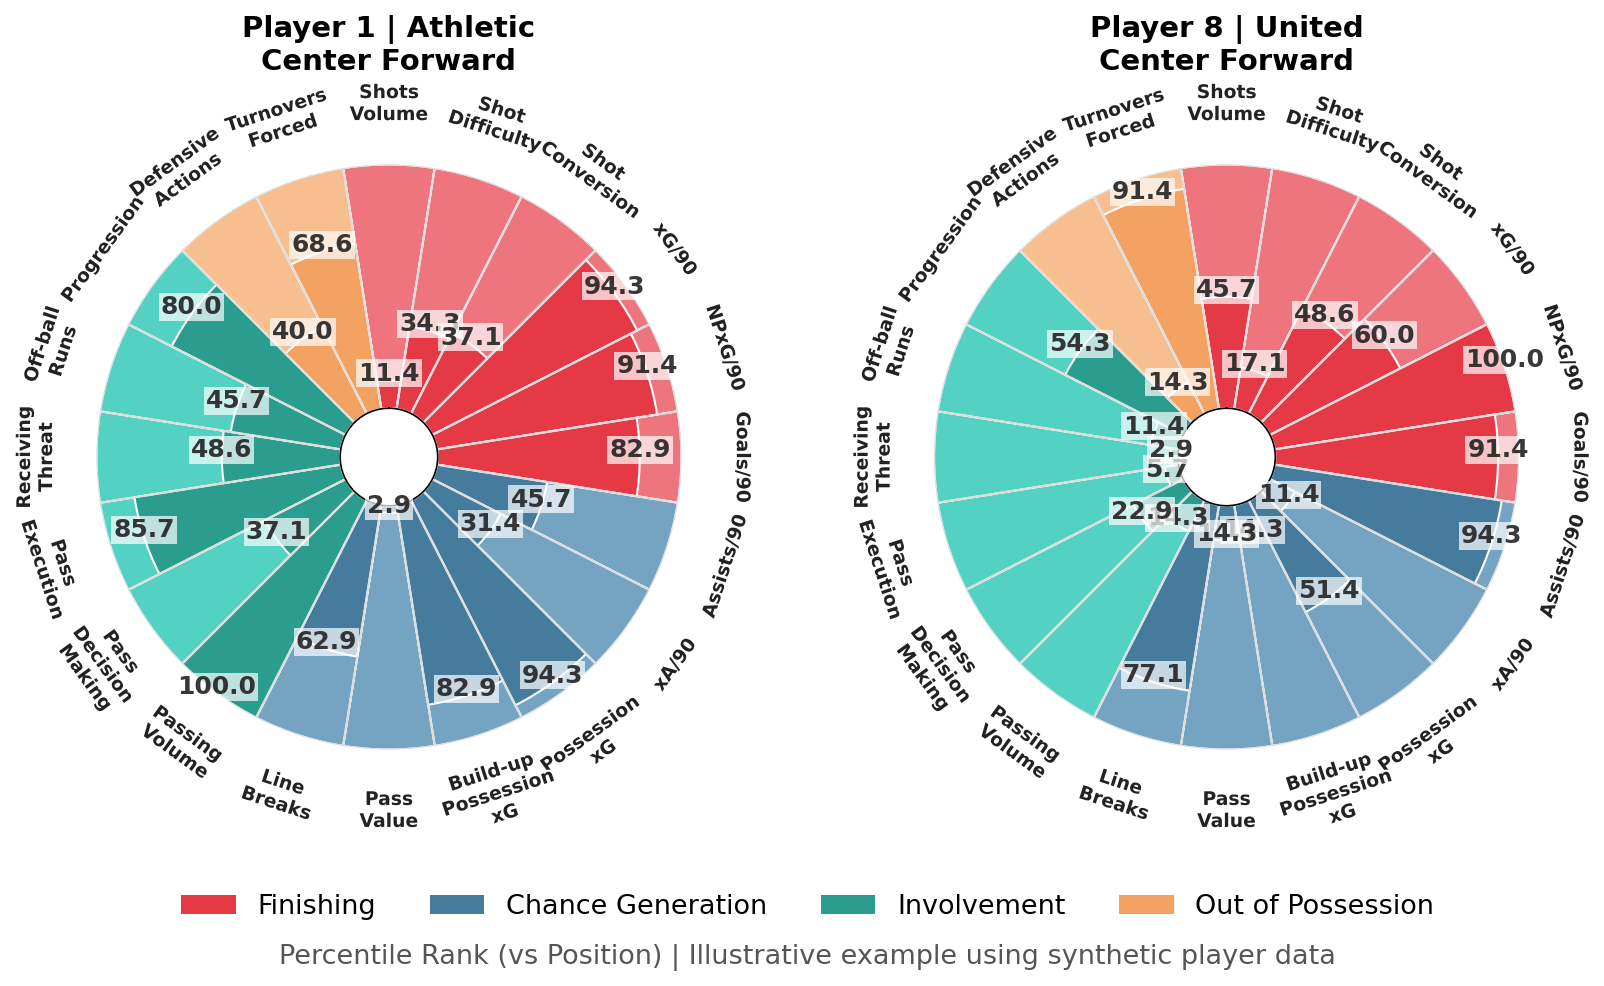

In [47]:
cf_players = df_fake[df_fake["position_group"] == "Center Forward"]

top_cf = cf_players.sort_values("NPxG90", ascending=False).iloc[0]["player_name"]

plot_player_profile(df_fake, ["Player 1", top_cf], mode="position")